In [18]:
%matplotlib inline

import jax.numpy as jnp
from jax import value_and_grad
from jax import random
from scipy.optimize import minimize
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as snb
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import multivariate_normal as mvn
import jax
import numpy as np
jax.config.update("jax_enable_x64", True)

# for plotting
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)

In [19]:
def add_colorbar(im, fig, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')
    
class Grid2D(object):
    """ helper class for evaluating the function func on the grid defined by (dim1, dim2)"""

    def __init__(self, dim1, dim2, func, name="Grid2D"):
        self.dim1 = dim1
        self.dim2 = dim2
        self.grid_size = (len(self.dim1), len(self.dim2))
        self.dim1_grid, self.dim2_grid = jnp.meshgrid(dim1, dim2, indexing='ij')
        self.func = func
        self.name = name
        
        # evaluate function on each grid point
        params_flat= jnp.column_stack((self.dim1_grid.flatten(), self.dim2_grid.flatten()))
        vals = self.func(params_flat)
        vals = jnp.asarray(vals).squeeze()
        if vals.size != params_flat.shape[0]:
            raise ValueError(
                f"Function output size {vals.size} does not match grid size {params_flat.shape[0]}"
            )
        self.values = vals.reshape(self.grid_size)
        # print(params_flat.shape)
        # print(self.func(params_flat))
        # self.values = self.func(params_flat).squeeze().reshape(self.grid_size)

    def plot_contours(self, ax, color='b', num_contours=10, f=lambda x: x, alpha=1.0, title=None):
        ax.contour(self.dim1, self.dim2, f(self.values).T, num_contours, colors=color, alpha=alpha)
        ax.set(xlabel='$w_1$', ylabel='$w_2$')
        ax.set_title(self.name, fontweight='bold')

    def plot_heatmap(self, ax, f=lambda x: x, clim=[0, 1], colorbar=False):
        img = ax.pcolormesh(self.dim1, self.dim2, f(self.values).T, cmap=plt.cm.RdBu_r, clim=clim)
        ax.set(xlabel='$w_1$', ylabel='$w_2$')
        ax.set_title(self.name, fontweight='bold')
        if colorbar:
            add_colorbar(img, ax.get_figure(), ax)

# Assignment 2 - 02477 Bayesian Machine Learning

Date: 09/04/2026

Bella Strandfort (s214215) & Sofie Ullum Jensen (s224185)

### Part 1: Gaussian processes and covariance functions

> Task 1.1: Determine the analytical marginal prior mean and variance of a Gaussian process for each of the covariance functions

Let's first write up the 6 covariance functions:
$$\begin{align}
k_1(x,x') &= 2\exp\left({-\frac{(x-x')^2}{2\cdot 0.3^2}}\right)\\
k_2(x,x') &= \exp\left({-\frac{(x-x')^2}{2\cdot 0.1^2}}\right)\\
k_3(x,x') &= 4+2xx'\\
k_4(x,x') &= \exp\left(-2\sin(3\pi \cdot|x-x'|)^2\right)\\
k_5(x,x') &= \exp\left(-2\sin(3\pi \cdot|x-x'|)^2\right)+4xx'\\
k_6(x,x') &= \frac{1}{5}+\min(x,x')
\end{align}$$

A Gaussian process is a prior distribution on the function space given by 
$$\begin{align*}
f(\mathbf{x}) \sim \mathcal{GP}\left(m(\mathbf{x}) \, , \, k\left(\mathbf{x}, \mathbf{x}'\right)\right)
\end{align*}$$

where 
$$\begin{equation}k\left(\mathbf{x}, \mathbf{x}'\right)=\mathbb{E}\left[\left(f(\mathbf{x})-m(\mathbf{x})\right)\left(f(\mathbf{x'})-m(\mathbf{x'})\right)\right] \tag{a}\end{equation}$$

is the covariance function. 

The mean of $f(x)$ is $m(x)$. From this we then have that:
$$
\mathbb{E}[f_i(x)]=m(x)=0
$$
for all $f_i(x)$

If we take the covariance function (a), to find $k(x,x)$ we get that 

$$\begin{align*}k\left(\mathbf{x}, \mathbf{x}'\right)&=\mathbb{E}\left[\left(f(\mathbf{x})-m(\mathbf{x})\right)\left(f(\mathbf{x})-m(\mathbf{x})\right)\right] = \mathbb{V}[f(x)] \end{align*}$$

wich means that $\mathbb{V}[f_i(x)]=k_i(x,x) $ for all $i=1,2,\dots, 6$. From this we get:

$$
\begin{align*}
\mathbb{V}[f_1(x)] &= 2\exp\left(-\frac{0^2}{2\cdot0.3^2}\right)=2\exp(0)=2\\
\mathbb{V}[f_2(x)] &= \exp\left(-\frac{0^2}{2\cdot0.1^2}\right)=\exp(0)=1\\
\mathbb{V}[f_3(x)] &= 4+2xx=4+2x^2\\
\mathbb{V}[f_4(x)] &= \exp\left(-2\sin(3\pi \cdot|x-x|)^2\right)=\exp(-2*0)=1\\
\mathbb{V}[f_5(x)] &= \exp\left(-2\sin(3\pi \cdot|x-x|)^2\right)+4xx=1+4x^2\\
\mathbb{V}[f_6(x)] &= \frac{1}{5}+\min(x,x)=\frac{1}{5}+x
\end{align*}
$$

<!-- Something like this explaination from week 6: 
By assumption, the prior mean of $f(\mathbf{x})$ is 0 for all $\mathbf{x}$. Therefore, $\mathbb{E}\left[\mathbf{f}\right] = \mathbb{0}$ and $\mathbb{E}\left[f^*\right] = 0$.
Moreover, the prior variance of $f(\mathbf{x})$ is $k(\mathbf{x}, \mathbf{x})$ for any $\mathbf{x}$, i.e. $\mathbb{V}\left[f(\mathbf{x})\right] = k(\mathbf{x}, \mathbf{x})$. Finally, the covariance between $f(\mathbf{x}^*)$ and $f(\mathbf{x})$ is given by $\text{cov}(f(\mathbf{x}^*), f(\mathbf{x})) = k(\mathbf{x}^*, \mathbf{x})$

Therefore, we have that $\mathbb{V}\left[\mathbf{f}\right] = \mathbf{K}$, $\mathbb{V}\left[f^*\right] = k(\mathbf{x}^*, \mathbf{x}^*)$, and $\text{cov}\left(\mathbf{f}, f^*\right) = \mathbf{k}$. Combining  this yields the multivariate normal distribution:

$$\begin{align*}
p(f^*, \mathbf{f}) = \mathcal{N}\left(\begin{bmatrix}f^*  \\ \mathbf{f}\end{bmatrix}|\begin{bmatrix}0 \\ \mathbf{0} \end{bmatrix}, \begin{bmatrix} k(\mathbf{x}^*, \mathbf{x}^*) & \mathbf{k}^T \\ \mathbf{k} & \mathbf{K} \end{bmatrix}\right)
\end{align*}
$$ -->

> Task 1.2: Which of the six covariance functions are stationary?

A covariance function is considered stationary if it only depends on the difference between two points in the input space, $\tau = \mathbf{x}_n - \mathbf{x}_m$. Therefore kernel function 1, 2 and 4 are stationary. Covariance function 3 is not because it depends on the product of the two and cannot be rewritten in terms of a difference between the two input points. One might be inclined to label covariance function 5 as stationary as well, since it does depend on the difference in two points. However, like covariance function 3, it also depend on the product of two points, which makes it non-stationary. Covariane function no. 6 is not stationary becuase it cannot be written as a difference.

> Task 1.3: Match the plot to the covariance function

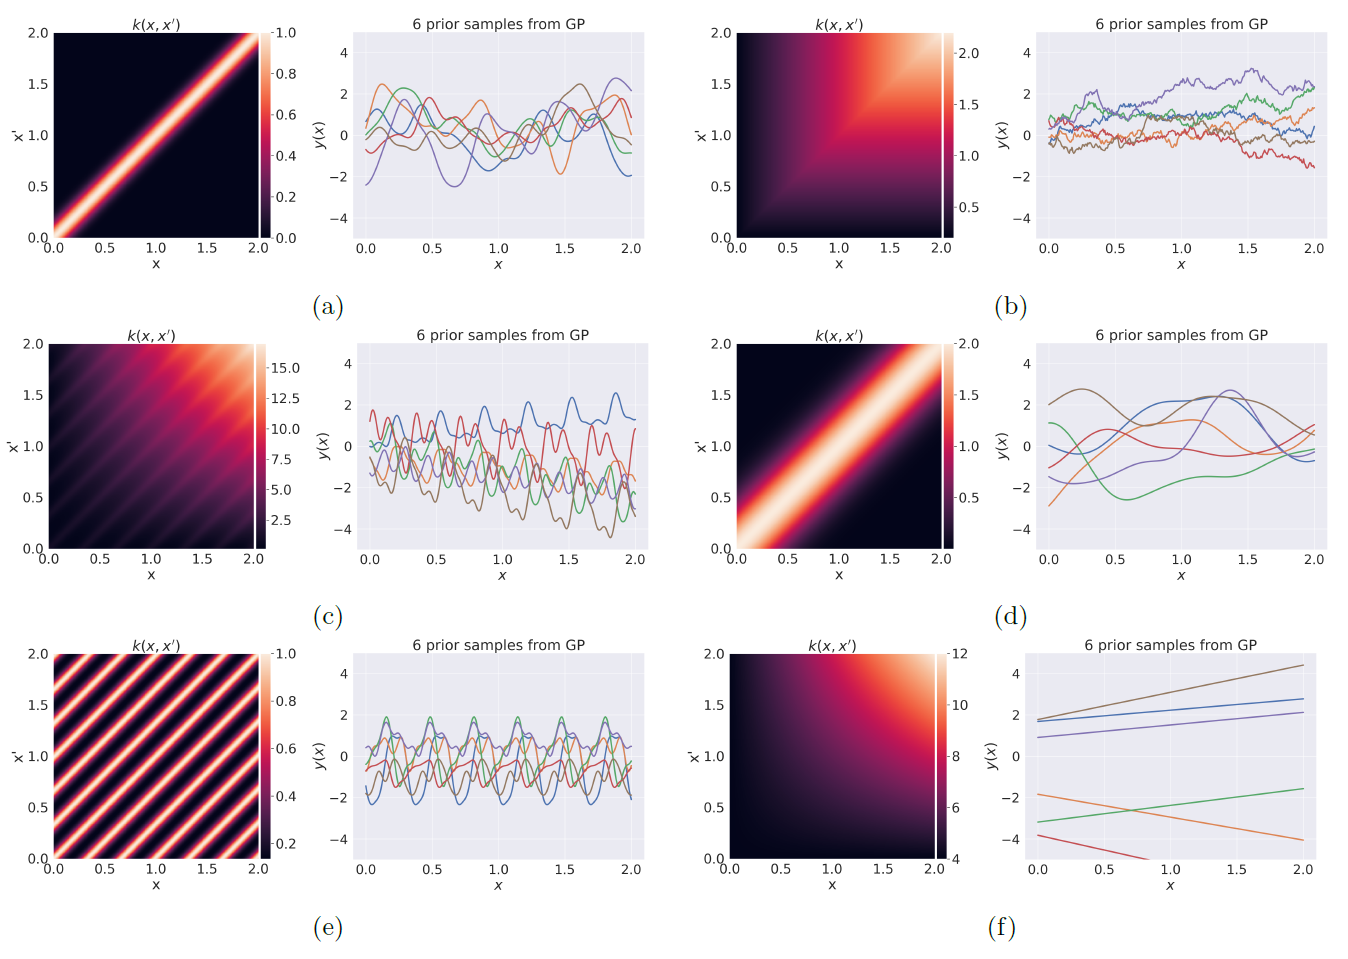

Kernel 6 matches plot (b), because we see that as we move along the diagional from (0,0) to (2,2), and look vertically or horizontal the color stays constant, because it is always the minimum value of $x$ and $x'$. 

Kernel 3 matches plot (f), because the range of values of the kernel is [4,12] and the samples must be linear because the kernel is linear in $x$

Kernel 4 matches plot (e) as it is a fully periodic kernel, which can be seen in the plot of the prior samples.

Kernel 5 matches plot (c), becuase the maximum value of the kernel is 17. We also see some sinoid behavoir in the samples because of the use of sinus in the kernel, however, it differs from plot (e), as it is a combined periodic and linear kernel. And whenever the difference between $x$ and $x'$ is $0$, then the kernel is just $4xx'$, which results in the lines in the kernel plot. 


Kernel 1 and 2 are squared exponential kernels. Kernel 1 has a bigger length scale and $\kappa$ value, and is therefore smoother than kernel 2. Therefore plot (d) matches kernel 1 and plot(a) matches kernel 2.

> Task 1.4: Implement the kernel function. Generate and plot S=30 realizations of the process for $x\in[-6,6]$ for $(\kappa_0,\kappa_1,\kappa_2,l)=(5,2,0,\frac{1}{2})$. Repeat for $(\kappa_0,\kappa_1,\kappa_2,l)=(5,0,1,\frac{1}{2})$ and $(\kappa_0,\kappa_1,\kappa_2,l)=(5,2,1,\frac{1}{2})$

In [20]:
  
def generate_samples(key, m, K, num_samples, jitter=0):
    zs = random.normal(key, shape=(len(K), num_samples))
    N = len(K)
    L = jnp.linalg.cholesky(K + jitter*jnp.identity(N))
    f_samples = L@zs + m[:, None]
    return f_samples

In [21]:
@dataclass
class Hyperparameters(object):
    kappa0:         float = 1.0
    kappa1:         float = 1.0
    kappa2:         float = 1.0
    lengthscale:    float = 1.0

    def to_array(self):
        """ return hyperparameters as flat JaX-array (to be used later) """
        return jnp.array([self.kappa0, self.kappa1, self.kappa2, self.lengthscale])
        
    @staticmethod
    def from_array(hyper_array):
        """ instantiates Hyperparameter object from flat JaX-array (or list) of hyperparameters (to be used later) """
        kappa0, kappa1, kappa2, lengthscale = hyper_array
        return Hyperparameters(kappa0, kappa1, kappa2, lengthscale)

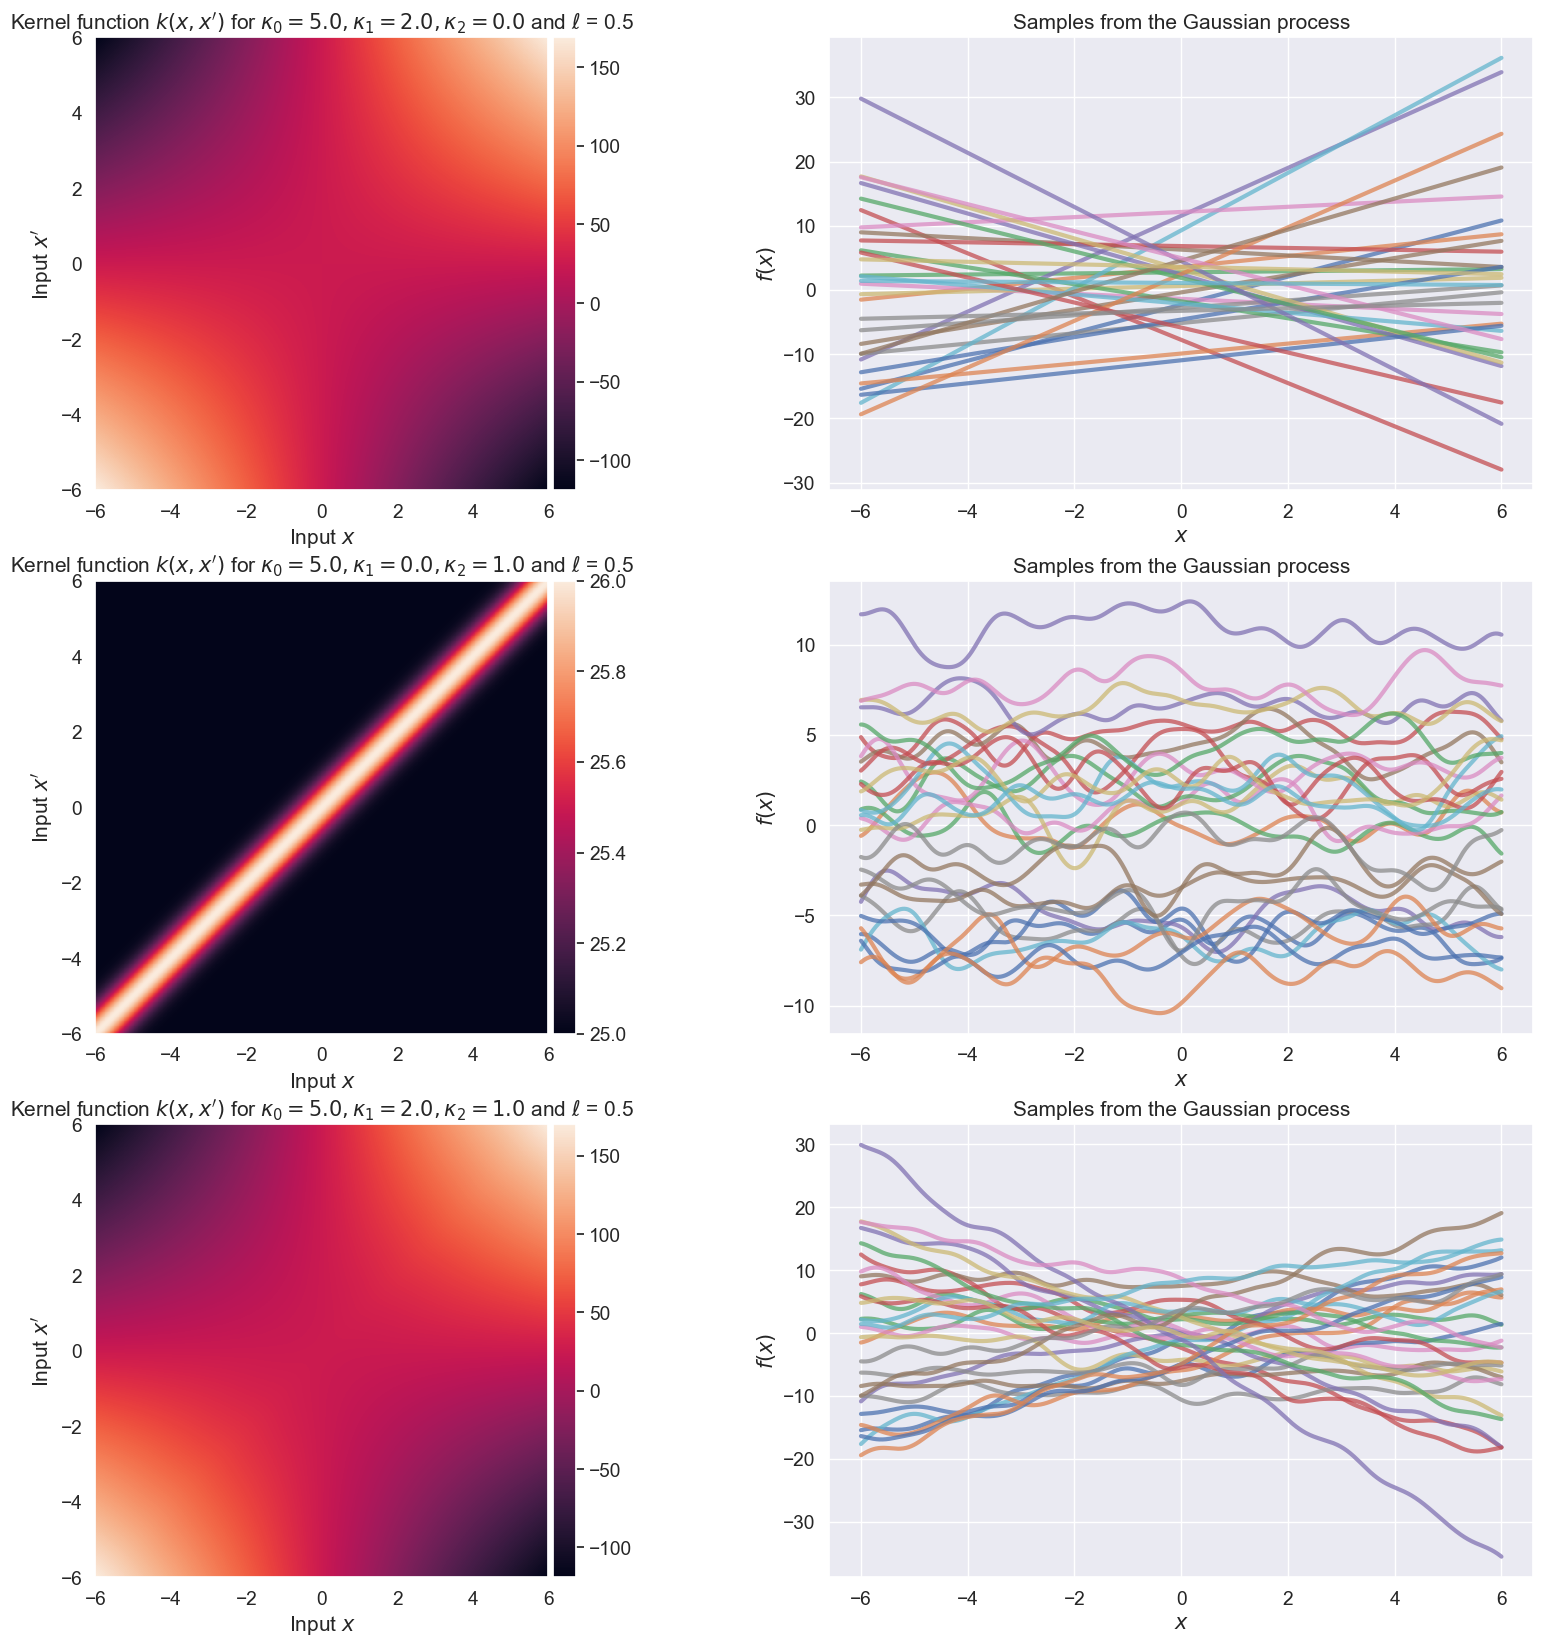

In [22]:
# create an Nx1 vector of equidistant points in [-6, 6]
N = 1000
X = jnp.linspace(-6, 6, N)[:, None]

# number of samples to be plotted
num_samples = 30

# specify random seed
key = random.PRNGKey(1)

# specify hyperparameters
hyper1 = Hyperparameters(kappa0=5.0, kappa1=2, kappa2=0, lengthscale=0.5)
hyper2 = Hyperparameters(kappa0=5.0, kappa1=0, kappa2=1, lengthscale=0.5)
hyper3 = Hyperparameters(kappa0=5.0, kappa1=2, kappa2=1, lengthscale=0.5)

# specify kernel
def kernel7(x, xm, hyper):
    diff = x[:, None] - xm
    return hyper.kappa0**2 + hyper.kappa1**2*jnp.dot(x, xm.T) + hyper.kappa2**2*jnp.exp(-0.5*jnp.sum(diff**2, axis=-1)/hyper.lengthscale**2)

hyperparameters = [hyper1, hyper2, hyper3]

# plot
fig, ax = plt.subplots(3, 2, figsize=(20, 20))

for i,hyper in enumerate(hyperparameters):
    # Generate kernel values
    K = kernel7(X,X,hyper)
    K += 1e-8*jnp.identity(len(X))

    # Plot kernel
    im = ax[i,0].pcolormesh(X.flatten(), X.flatten(), K, shading='auto')
    ax[i,0].set(xlabel='Input $x$', ylabel="Input $x'$", title=f"Kernel function $k(x, x')$ for $\\kappa_0 = {hyper.kappa0:2.1f}, \\kappa_1 = {hyper.kappa1:2.1f}, \\kappa_2 = {hyper.kappa2:2.1f}$ and $\\ell$ = {hyper.lengthscale:2.1f}")
    ax[i,0].grid(False)
    ax[i,0].set_aspect('equal')
    add_colorbar(im, fig, ax[i,0])

    m = jnp.zeros(len(X))
    f_samples = generate_samples(key, m, K, num_samples=num_samples, jitter=1e-8)
    ax[i,1].plot(X, f_samples, alpha=0.75, linewidth=3);
    ax[i,1].grid(True)
    ax[i,1].set(xlabel='$x$', ylabel='$f(x)$', title='Samples from the Gaussian process');


### Part 2: Laplace approximation for a simple neural network

> Task 2.1: Generate S=100 samples from the prior p(w) and plot the corresponding functions for f(x) for $x\in[0,10]$ on top of a scatter plot of the data

In the plot below 100 samples from the prior $p(w)$, their corresponding functions $f(x)$ for $x \in [0,10]$ on top of a scatterplot of the data

In [23]:
key = random.PRNGKey(123)
keys = random.split(key)

In [24]:
tau = 2
beta = 4
N = 100
S = 100

x = np.array([9.589,7.375,4.647,2.501,2.538,6.783,4.294,5.111,0.130, 0.783])
y = np.array([3.032,3.349,2.906,2.126,1.538,2.787,3.078,2.993,0.828,-0.331])

w = [tau*random.normal(keys[0], shape=(S, 1)),
     tau*random.normal(keys[1], shape=(S,1))]

sigmoid = lambda x: 1./(1 + jnp.exp(-x))

f = lambda w0, w1, x: w1*sigmoid(x + w0)

(0.0, 10.0)

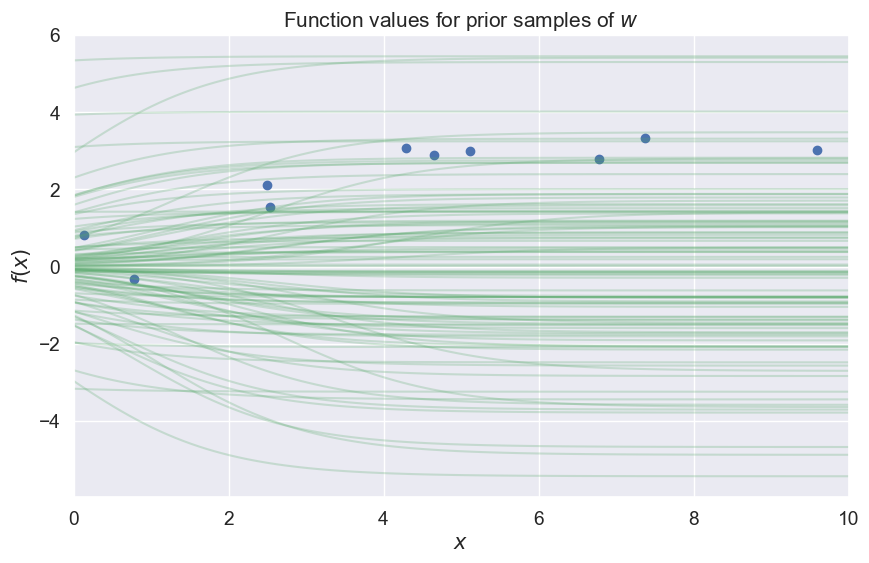

In [25]:
X = jnp.linspace(0, 10, N)[:, None]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.scatter(x,y)
for i in range(S):
    ax.plot(X, f(w[0][i], w[1][i], X), color='g', alpha=.25)

ax.grid(True)
ax.set(xlabel='$x$', ylabel='$f(x)$', title='Function values for prior samples of $w$');
ax.set_xlim(0,10)

> Task 2.2: What prevents us from using the equations in section 3.3 in Murphy1 to compute the exact posterior distribution of the parameters given the data analytically for the system in eq. 14?

The joint density for $(\mathbf{y},\mathbf{w})$ is
$$
\begin{equation}
p(\mathbf{y},\mathbf{w})=p(\mathbf{w})\Pi_{n=1}^Np(y_n|x_n,\mathbf{w})=\mathcal{N}(w_0|0,\tau^2)\mathcal{N}(w_1|0,\tau^2)\Pi_{n=1}^N\mathcal{N}(y_n|w_1\sigma(x_n+w_0),\beta^{-1}) \tag{14}
\end{equation}
$$

Even though the prior is Gaussian, the likelihood function involves a non-linear transformation through the sigmoid function. Because of this non-linearity the conjugacy is broken, which means it isn't possible to compute the posterior distribution in closed form, and it is therefore necessary to estimate it using Laplace.

<!-- Because our prior and our likelihood are products of random variables, they follow complex distributions and we cannot easily recognize the mean and variance of these distributions, so we cannot use the equations from Murphy1 <- this might only be for the likelihood> -->

> Task 2.3: Implement a python function for evaluating the logarithm of the joint density in eq. (14). Report the nummerical value of $\log p(y,w)$ for the dataset given above when $w_0=w_1=0$

In the cell below is a function for the log joint density function

In [26]:
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*jnp.log(2*jnp.pi*v)

def log_joint_density(tau, beta, w0, w1, x, y):

    # # csum = 2*np.log(1/np.sqrt(2*np.pi)) + 2*np.log(1/tau) - (w0**2 + w1**2)/(2*tau**2)
    # csum = log_npdf(w0, 0, tau**2) + log_npdf(w1, 0, tau**2)
    # N = len(x)

    # for n in range(N):
    #     # csum += np.log(1/np.sqrt(2*np.pi)) + np.log(1/np.sqrt(1/beta)) - (y[n]-w1*sigmoid(x[n]+w0))**2/(2*(1/beta))
    #     csum += log_npdf(y[n], w1*sigmoid(x[n]+w0), beta**(-1))
    N = len(x)
    v = sigmoid(x[:, None] + w0)
    inter = y[:, None] - w1 * v
    # inter = y - w1*sigmoid(x+w0)
    joint = -jnp.log(2*jnp.pi*tau**2) - (w0**2 + w1**2)/(2*tau**2) - N/2*jnp.log(2*jnp.pi/beta) - beta/2*jnp.sum(inter**2,axis=0)
    return joint

In [27]:
print(log_joint_density(tau, beta, 0, 0, x, y))

[-130.94934095]


The nummerical value of $\log p(y,w)$ for the dataset given above when $w_0=w_1=0$, is thus approximately $-130.94$

> Task 2.4: Determine the expression for the gradient and the Hessian of the logarithm of the joint density wrt. w

First, lets write down the logarithm of the joint density:

$$
\log\mathcal{N}(w_0|0,\tau^2) + \log\mathcal{N}(w_1|0,\tau^2) + \sum_{n=1}^{N}{\log \mathcal{N}(w_1\sigma (x_n + w_0), \beta^{-1})}
$$

The gradient of the logarithm of the joint density wrt. $\mathbf{w}$ is the first order derivative of the of the function, and the Hessian is the second order derivative. From this we get that the gradient is:

$$
\begin{align*}
&\nabla _{\mathbf{w}} \log p(\mathbf{y,\mathbf{w}})=\begin{bmatrix}
\frac{\partial}{\partial w_0} \log p(\mathbf{y,\mathbf{w}})\\
\frac{\partial}{\partial w_1} \log p(\mathbf{y,\mathbf{w}})
\end{bmatrix}= \begin{bmatrix}
-\frac{w_0}{\tau^2} + \beta w_1\sum_{n=1}^N r_n \sigma_n(1-\sigma_n)\\
-\frac{w_1}{\tau^2} + \beta\sum_{n=1}^N r_n \sigma_n
\end{bmatrix}
\end{align*}
$$
where $\sigma_n = \sigma(x_n+w_0) $ and $r_n = y_n-w_1$.

The Hessian then becomes:
$$\mathbf{H} = \begin{bmatrix}
-\frac{1}{\tau^2} - \beta w_1^2 \sum_{n=1}^N [\sigma_n(1-\sigma_n)]^2 + \beta w_1 \sum_{n=1}^N r_n \sigma_n(1-\sigma_n)(1-2\sigma_n) &
\beta\sum_{n=1}^N\sigma_n(1-\sigma_n)(r_n - 2w_1\sigma_n)\\
\beta\sum_{n=1}^N\sigma_n(1-\sigma_n)(r_n - 2w_1\sigma_n) &
-\frac{1}{\tau^2} - \beta\sum_{n=1}^N\sigma_n^2
\end{bmatrix}$$

> Task 2.5: Determine the Laplace approximation q(w) of the posterior distribution 

We want to do a Laplace approximate of our posterior distribution $p(w|y)$. The Laplace approximation is defined as:
$$ q(w) = \mathcal{N}(w|w_{\text{MAP}}, A^{-1})$$
where $w_{\text{MAP}}$ is the mode and $A$ is the Hessian at the mode. The mode is found at the maximum of the joint distribution: $w_{\text{MAP}} = \text{argmax}_w p(w|y) = \text{argmax}_w p(y|w)p(w) = \text{argmax}_w p(y,w)$, specifically $w_{\text{MAP}} = \text{argmax}_w \log p(y,w)$, and $A^{-1}$ is found by evaluating the expression of the Hessian found above at $w_{\text{MAP}}$ 

In [28]:
class mGaussian(object):
    def __init__(self, x, y, N, tau, beta):

        # data
        self.x, self.y, self.N = x, y, N

        # hyperparameters
        self.tau, self.beta = tau, beta

        self.D = 2

        self.w_MAP = self.get_MAP()
   
    def log_joint(self, w_):
        """ evaluates and return the log joint p(y, theta_) """
        if w_.ndim == 2:
            w0, w1 = w_[:, 0], w_[:, 1]
        else:
            w0, w1 = w_[0], w_[1]
        lj = log_joint_density(self.tau, self.beta, w0, w1, self.x, self.y)
        return lj

    def grad(self, w_):
        """ evaluates and return the gradient of the log joint p(y, theta) write to theta evaluated at theta_ """ 
        w0, w1 = w_[0], w_[1]
        v = sigmoid(x+w0)
        gradient = jnp.array([-w0/tau**2 + beta*jnp.sum((y-w1*v)*v*(1-v)*w1),
                              -w1/tau**2 + beta*jnp.sum((y-w1*v)*v)])
        
        return gradient.ravel()

    def hessian(self, w_):
        """ evaluates and return the hessian of the log joint p(y, theta) write to theta evaluated at theta_ """
        w0, w1 = w_[0], w_[1]
        v = sigmoid(x+w0)
        hess = jnp.array([[-tau**(-2) + beta*jnp.sum(-w1**2 * (v*(1-v))**2 + (1-2*v)*v*(1-v)*w1*(y-w1*v)),
                            beta*jnp.sum(v*(1-v)*(y-2*w1*v))],
                            [beta*jnp.sum(v*(1-v)*(y-2*w1*v)),
                            -tau**(-2) - beta*jnp.sum(v**2)]])
        return hess
    
    def get_MAP(self):
        init_w = np.zeros(2)

        results = minimize(
            lambda x: -self.log_joint(x), 
            jac=lambda x: -self.grad(x), 
            x0=init_w,
            method = "L-BFGS-B")

        if not results.success:
            print(results)
            raise ValueError('Optization failed')
        
        w_MAP = results.x 
        return w_MAP

In [29]:
class LaplaceApproximation(object):

    def __init__(self, model):
        """ implements a laplace approximain q(w) = N(m, S), where m is the posterior mean and S is the posterior covariance """

        # store model
        self.model = model

        # implement Laplace approximation
        self.posterior_mean = model.w_MAP                               
        self.posterior_hessian = model.hessian(model.w_MAP)             
        self.posterior_cov = -jnp.linalg.inv(self.posterior_hessian)     

        # sanity check for dimensions
        assert self.posterior_mean.shape == (model.D,), f"The shape of the posterior mean appears wrong. Check your implementaion."
        assert self.posterior_hessian.shape == (model.D, model.D), f"The shape of the posterior Hessian appears wrong. Check your implementaion."
        assert self.posterior_cov.shape == (model.D, model.D), f"The shape of the posterior covariance appears wrong. Check your implementaion."

    def log_pdf(self, w):
        """ evaluate approximate posterior density at w """
        return mvn.logpdf(w, self.posterior_mean.ravel(), self.posterior_cov)
    
    def posterior_samples(self, key, num_samples):
        """ generate samples from posterior distribution """
        return random.multivariate_normal(key, self.posterior_mean, self.posterior_cov, shape=(num_samples, ))

model = mGaussian(x, y,  N, tau, beta)
laplace = LaplaceApproximation(model)

In [30]:
print(f"The mean of the Laplace approximation: {jnp.round(laplace.posterior_mean,2)}")
print(f"The variance of the Laplace approximation: {jnp.round(laplace.posterior_cov,2)}")

The mean of the Laplace approximation: [-2.2  3.1]
The variance of the Laplace approximation: [[ 0.17 -0.05]
 [-0.05  0.05]]


> Task 2.6: Create a 2D contour plot of the posterior of the parameters. Plot the contours of the Laplace approximation on top of the plot to validate results

C:\Users\sofie\AppData\Local\Temp\ipykernel_20156\2845192964.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


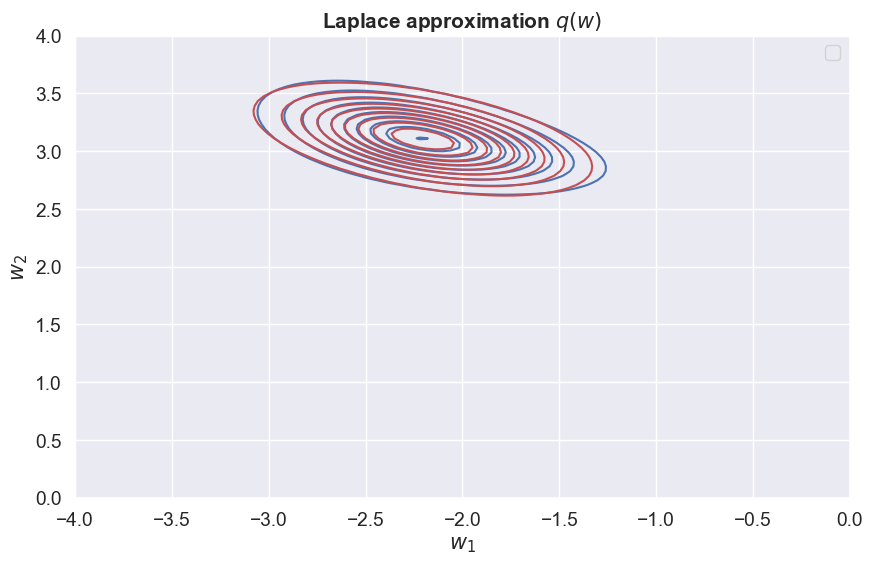

In [31]:
dim1, dim2 = jnp.linspace(-4, 0, 100), jnp.linspace(0, 4, 100)
grid_log_joint = Grid2D(dim1, dim2, model.log_joint,  name='Posterior distribution $p(w|y)$')
grid_log_laplace = Grid2D(dim1, dim2, laplace.log_pdf, name='Laplace approximation $q(w)$')

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
grid_log_joint.plot_contours(ax, f=jnp.exp) # Plots the posterior in original data space
grid_log_laplace.plot_contours(ax, f=jnp.exp, color='r')
ax.legend()
plt.show()

> Task 2.7: Generate and plot S=100 samples from the approximate posterior. Plot the corresponding function f(x) for $x\in[0,10]$ on top of scatter plot of the data

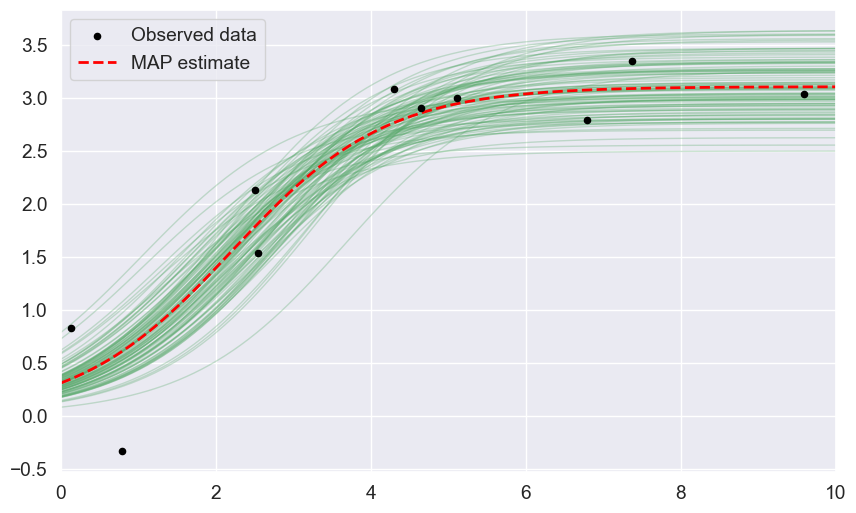

In [32]:
# generate samples from posterior
key = random.PRNGKey(1)
S = 100
w_samples = laplace.posterior_samples(key, S)
x_range = jnp.linspace(0, 10, 100)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for i in range(S):
    w_0, w_1 = w_samples[i]
    y_pred = f(w_0,w_1, x_range)
    ax.plot(x_range, y_pred, 'g', alpha=0.3, lw=1)
ax.scatter(x, y, color='black', zorder=3, label='Observed data', s=20)
ax.plot(x_range, f(model.w_MAP[0], model.w_MAP[1],x_range), color='red', lw=2, linestyle='--', label='MAP estimate')
ax.set_xlim(0,10)
ax.legend();


> Task 2.8: Use the Laplace approximation to compute the approximate posterior probability for the event $f(8)>3$

In [33]:
x_star = 8

# MC estimate
key = random.PRNGKey(2)
w_samples = laplace.posterior_samples(key, 5000)

count = 0
for i in range(5000):
    w0_s = w_samples[i, 0]
    w1_s = w_samples[i, 1]
    
    # Calculate f(8) for this specific sample
    val = f(w0_s, w1_s, 8)
    
    if val > 3:
        count += 1

print(f"Probability: {count/5000:.2}")

Probability: 0.66


From this we get taht the probability of the event $f(8)>3$ is approximately $0.66$

> Task 2.9: Determine the mean and a 95% interval for the approximate predictive distribution for $x^*=3.75$ 

In [34]:
# Again using a MC estimate

xstar = jnp.array([3.75])
key = random.PRNGKey(3)
w_samples = laplace.posterior_samples(key, 5000)

f_samples = f(w_samples[:,0], w_samples[:,1], xstar)

mean = jnp.mean(f_samples)
lower, upper = jnp.percentile(f_samples, jnp.array([2.5, 97.5]))

print(f"Mean of predictive distribution: {mean:.2}")
print(f"95% interval: [{lower:.2},{upper:.2}]")

Mean of predictive distribution: 2.5
95% interval: [2.1,2.9]
